# Oppg 2

In [3]:
import scipy as sp
from functools import partial
from tqdm import tqdm
import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True) # Gir oss muligheten til å bruke complex128 og float64
import matplotlib.pyplot as plt

## 2a)

In [4]:
@jax.jit
def C2x2MatrixToR8Vector(matrix):
    real = jnp.real(matrix)
    imag = jnp.imag(matrix)

    return jnp.concat([real, imag]).flatten()

@jax.jit
def R8VectorToC2x2Matrix(vec):
    matrix = jnp.reshape(vec, (2,2,2))
    matrix = matrix[0] + 1j*matrix[1]

    return matrix


#Testing
test_matrices = list()
for i in range(4):
    key_real = jax.random.key(45+i)
    key_imaginary = jax.random.key(60+i)
    real_part = jax.random.randint(key_real, shape=(2,2), minval=0, maxval=20)
    imaginary_part = 1j*jax.random.randint(key_imaginary, shape=(2,2), minval=0, maxval=20)
    final_matrix = real_part + imaginary_part
    test_matrices.append(final_matrix)


def check_if_equal(m1, m2):
    if jnp.all(m1 == m2):
        return True
    else:
        return False

R8vectors = [C2x2MatrixToR8Vector(v) for v in test_matrices]
for vector, original_matrix in zip(R8vectors, test_matrices):
    print(f"Form på vektor: {vector.shape}")
    has_correct_form = jnp.all(vector[:4].reshape(2,2) == jnp.real(original_matrix)) and jnp.all(vector[4:].reshape(2,2) == jnp.imag(original_matrix))
    print(f"Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: {has_correct_form}\n")


C2x2Matrices = [R8VectorToC2x2Matrix(v) for v in R8vectors]
identical = True
for (transformed_matrix, original_matrix) in zip(test_matrices, C2x2Matrices):
    is_equal = check_if_equal(transformed_matrix, original_matrix)
    if not is_equal:
        identical = False
        break

if not identical:
    print("Funksjonene fungerer ikke som de skal")
else:
    print("Alle matrisene er identiske etter transformasjon tilbake")
    


Form på vektor: (8,)
Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: True

Form på vektor: (8,)
Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: True

Form på vektor: (8,)
Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: True

Form på vektor: (8,)
Vektor har form [a1,a2,a3,a4,b1,b2,b3,b4]: True

Alle matrisene er identiske etter transformasjon tilbake


Funksjonene virker som de skal. Vi satte opp et par matriser i $\mathbb{C}^{2x2}$ med unike elementer og satte dem som argumenter til $f : \mathbb{C}^{2x2} \rightarrow \mathbb{R}^8$ og verifiserte at det som kom ut var på formen $\left[ a_1 ,a_2,a_3,a_4,b_1,b_2,b_3,b_4\right]$. Deretter transformerte vi tilbake og sammenlignet resultatet med de originale matrisene.

## 2b)

In [5]:
@jax.jit
def MergeVectors(m1, m2, m3, m4):
    tmp_arr = jnp.concat([m1,m2,m3,m4])
    return tmp_arr.flatten()

@jax.jit
def SplitVectors(m1):
    return m1.reshape(4, 8)


#Testing
test_vectors = list()
for i in range(4):
    key = jax.random.key(45+i)
    vector = jax.random.randint(key_real, shape=(8,), minval=0, maxval=20)
    test_vectors.append(vector)

transformed_vectors = SplitVectors(MergeVectors(test_vectors[0], test_vectors[1], test_vectors[2], test_vectors[3]))

is_identical = jnp.all(jnp.array(test_vectors) == transformed_vectors)

if is_identical:
    print("Vektorene er identisk etter å ha blitt transformert og invers-transformert")
else:
    print("Funksjonene virker ikke som de skal")

Vektorene er identisk etter å ha blitt transformert og invers-transformert


Her laget vi fire vektorer med form (8,) og brukte MergeVectors og deretter SplitVectors på resultatene. Deretter sjekket vi om dette objektet var identisk med det vi startet med, noe den var.

## 2c)

In [6]:
@jax.jit
def convert_matrices_to_vector(m1, m2, m3, m4):
    matrix_list = [m1, m2, m3, m4]
    real_vectors = [C2x2MatrixToR8Vector(m) for m in matrix_list]
    v = MergeVectors(real_vectors[0], real_vectors[1], real_vectors[2], real_vectors[3])
    return v

@jax.jit
def convert_vector_to_matrices(v):
    real_vectors = SplitVectors(v)
    m1, m2, m3, m4 = [R8VectorToC2x2Matrix(x) for x in real_vectors]
    return m1, m2, m3, m4

test_matrices = list()
for i in range(4):
    key_real = jax.random.key(45+i)
    key_imaginary = jax.random.key(60+i)
    real_part = jax.random.randint(key_real, shape=(2,2), minval=0, maxval=20)
    imaginary_part = 1j*jax.random.randint(key_imaginary, shape=(2,2), minval=0, maxval=20)
    final_matrix = real_part + imaginary_part
    test_matrices.append(final_matrix)

vector = convert_matrices_to_vector(test_matrices[0], test_matrices[1], test_matrices[2], test_matrices[3])
print("Matriser:\n")
print(test_matrices[0], '\n\n', test_matrices[1], '\n\n', test_matrices[2], '\n\n', test_matrices[3], '\n\n')
print("Vektor:")
print(vector)

Matriser:

[[ 9.+12.j 11. +4.j]
 [ 8.+19.j 19. +3.j]] 

 [[9. +5.j 5.+10.j]
 [7. +5.j 4. +2.j]] 

 [[7. +9.j 4.+19.j]
 [6.+15.j 1. +0.j]] 

 [[ 1.+18.j 13.+19.j]
 [ 6. +2.j 14. +6.j]] 


Vektor:
[ 9. 11.  8. 19. 12.  4. 19.  3.  9.  5.  7.  4.  5. 10.  5.  2.  7.  4.
  6.  1.  9. 19. 15.  0.  1. 13.  6. 14. 18. 19.  2.  6.]


Som outputen ovenfor viser er vektoren satt opp slik at 8 etterfølgende komponenter (fra start) representerer en av de originale komplekse matrisene, med formatet som vist i 2a)

## 2d)

In [7]:
@jax.jit
def calc_N(gamma, gamma_tilde):
    N = jnp.linalg.inv(jnp.identity(2) - jnp.einsum('ij, jk', gamma, gamma_tilde))
    return N

@jax.jit
def calc_N_tilde(gamma, gamma_tilde):
    N_tilde = jnp.linalg.inv(jnp.identity(2) - jnp.einsum('ij, jk', gamma_tilde, gamma))
    return N_tilde

@jax.jit
def calc_dv(v, eps, delta):
    'Derivert av v-vektoren (32x1)'
    gamma, gamma_tilde, omega, omega_tilde = convert_vector_to_matrices(v)

    gamma_derivative = omega
    gamma_tilde_derivative = omega_tilde

    N = calc_N(gamma, gamma_tilde)
    N_tilde = calc_N_tilde(gamma, gamma_tilde)

    omega_derivative = -2j * (eps + 1j*delta) * gamma - 2* jnp.einsum('ij,jk,kl,lm', omega, N_tilde, gamma_tilde, omega)
    omega_tilde_derivative = -2j * (eps + 1j*delta) * gamma_tilde - 2* jnp.einsum('ij,jk,kl,lm', omega_tilde, N, gamma, omega_tilde)

    dv = convert_matrices_to_vector(gamma_derivative, gamma_tilde_derivative, omega_derivative, omega_tilde_derivative)
    return dv

## 2e)

In [8]:
@jax.jit
def calc_dvec(x: jnp.array, vec : jnp.array, eps, delta):
    'Derivert av matrise av v-vektorer'
    dvec = jax.vmap(calc_dv, in_axes=(1, None, None), out_axes=1)(vec, eps, delta)
    return dvec

## 2f)

In [9]:
@jax.jit
def calc_boundary_normmetals(v_left,v_right, zeta, l):
    'Beregning av grensebetingelser for system av kun normale metaler, dvs alle ricatti-matriser i grenser er null'
    gamma_left, gamma_left_tilde, omega_left, omega_left_tilde = convert_vector_to_matrices(v_left)
    gamma_right, gamma_right_tilde, omega_right, omega_right_tilde = convert_vector_to_matrices(v_right)

    N_left = calc_N(gamma_left, gamma_left_tilde)
    N_left_tilde = calc_N_tilde(gamma_left, gamma_left_tilde)

    N_right = calc_N(gamma_right, gamma_right_tilde)
    N_right_tilde = calc_N_tilde(gamma_right, gamma_right_tilde)

    eq13 = omega_right + jnp.einsum('ij,jk,kl', 1/(zeta*l) * jnp.identity(2), N_right, -gamma_right)
    eq14 = omega_right_tilde + jnp.einsum('ij,jk,kl', 1/(zeta*l) * jnp.identity(2), N_right_tilde, -gamma_right_tilde)

    eq15 = omega_left - jnp.einsum('ij,jk,kl', 1/(zeta*l) * jnp.identity(2), N_left, -gamma_left)
    eq16 = omega_left_tilde - jnp.einsum('ij,jk,kl', 1/(zeta*l) * jnp.identity(2), N_left_tilde, -gamma_left_tilde)

    final_v = convert_matrices_to_vector(eq13, eq14, eq15, eq16)
    return final_v

## 2g) 

In [10]:
def oppgave_2g():
    epsilon = jnp.array([2,1,0])
    lengths = l = 1
    delta = 0.01
    zeta = 3
    xm = 101

    y_all_energies = list()
    y = jnp.zeros((32,xm))
    x = jnp.linspace(0,l,xm)
    for eps in tqdm(epsilon):
        
        #Bruker partial for å fryse parameterverdier (epsilon, delta osv.) for å kunne bruke funksjonen i solve_bvp
        partial_dvec = partial(calc_dvec, eps=eps, delta=delta)
        partial_boundary = partial(calc_boundary_normmetals, zeta=zeta, l=l)
        sol = sp.integrate.solve_bvp(partial_dvec, partial_boundary, x, y, max_nodes = xm)
        y = sol['y']
        y_all_energies.append(y)

    return x, jnp.array(y_all_energies)


x, y_all_energies = oppgave_2g()
sum_solution_not_zero = (~jnp.isclose(y_all_energies, 0)).sum() # Teller antall verdier der løsning IKKE er 0
print(f"Antall punkter der løsning ikke er null: {sum_solution_not_zero}")


100%|██████████| 3/3 [00:01<00:00,  2.74it/s]

Antall punkter der løsning ikke er null: 0


Vi løser systemet med begge grenseverdiene lik null og med begge gjetningene lik null. Dermed vil den deriverte i alle likningene 9-12 ende med å være lik null. Dette gjelder også for likning 13-16. Derfor forventer vi at alle løsningsvektorene blir null, og dermed at tilstandstettheten vil bli konstant. Dette stemmer; *solve_bvp* returnerer alle løsningsvektorer lik $\vec{0}$. Dette gir mening ettersom vi essensielt ser på tre vanlige metaller plassert ved siden av hverandre, noe som betyr at det ikke er noen superledere tilstede som har mulighet for å "lekke inn" i det normale metallet.

## 2h)

100%|██████████| 3/3 [00:00<00:00, 20.79it/s]


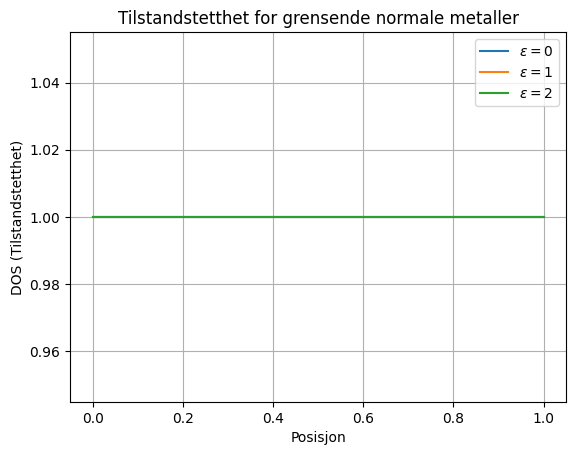

In [11]:
@jax.jit
def CalculateGreensFunction(solution):

    gamma, gamma_tilde, omega, omega_tilde = convert_vector_to_matrices(solution)

    N = calc_N(gamma, gamma_tilde)
    N_tilde = calc_N_tilde(gamma, gamma_tilde)

    topLeft = 2*N - jnp.identity(2)
    topRight = 2*N @ gamma
    bottomLeft = -2*N_tilde @ gamma_tilde
    bottomRight = -2*N_tilde + jnp.identity(2)

    greens = jnp.block([[topLeft, topRight], [bottomLeft, bottomRight]])
    return greens

@jax.jit
def CalculateDensityOfState(greensFunction): 
    roHat3 = jnp.array(((1,0,0,0),(0,1,0,0),(0,0,-1,0),(0,0,0,-1)))
    density = jnp.real(jnp.einsum("ii",roHat3 @ greensFunction)) / 4
    density = density.reshape(-1, 1)
    return density

def oppgave_2h():
    
    x, y_all_energies = oppgave_2g()
    for idx, y in enumerate(y_all_energies):
        greensFunctions = jax.vmap(CalculateGreensFunction, in_axes=1)(y)
        density = jax.vmap(CalculateDensityOfState)(greensFunctions).flatten()
        plt.plot(x, density, label=f"$\\varepsilon = {idx}$")
    
    plt.grid()
    plt.legend()
    plt.xlabel("Posisjon")
    plt.ylabel("DOS (Tilstandstetthet)")
    plt.title("Tilstandstetthet for grensende normale metaller")
    plt.show()

oppgave_2h()

## 2i)

In [12]:
@jax.jit
def nuPluss(eps, delta):
    return jnp.arctanh(1/(eps + delta*1j))

@jax.jit
def nuMinus(eps, delta):
    return jnp.arctanh(-1/(eps + delta*1j))

@jax.jit
def fetch_nonzero_riccati(eps, delta, phaseL = 0, phaseR = 0):
    plussElement = jnp.sinh(nuPluss(eps, delta))/(1+jnp.cosh(nuPluss(eps, delta)))
    minusElement = jnp.sinh(nuMinus(eps, delta))/(1+jnp.cosh(nuMinus(eps, delta)))

    material_gamma_left = jnp.array(((0, plussElement),(minusElement, 0)))*jnp.exp(phaseL*1j)
    material_gamma_tilde_left = jnp.array(((0, minusElement),(plussElement, 0)))*jnp.exp(-phaseL*1j)

    material_gamma_right = jnp.array(((0, plussElement),(minusElement, 0)))*jnp.exp(phaseR*1j)
    material_gamma_tilde_right = jnp.array(((0, minusElement),(plussElement, 0)))*jnp.exp(-phaseR*1j)
    
    return material_gamma_left, material_gamma_tilde_left, material_gamma_right, material_gamma_tilde_right

@jax.jit
def calc_boundary_superconduct_metals(v_left,v_right, eps, delta, zeta, l, phiL, phiR):
    'Beregning av grensebetingelser for ikke-null riccati-matriser'
    gamma_left, gamma_left_tilde, omega_left, omega_left_tilde = convert_vector_to_matrices(v_left)
    gamma_right, gamma_right_tilde, omega_right, omega_right_tilde = convert_vector_to_matrices(v_right)

    material_gamma_left, material_gamma_left_tilde, material_gamma_right, material_gamma_right_tilde = fetch_nonzero_riccati(eps, delta, phiL, phiR)

    N_left = calc_N(material_gamma_left, material_gamma_left_tilde)
    N_left_tilde = calc_N_tilde(material_gamma_left, material_gamma_left_tilde)

    N_right = calc_N(material_gamma_right, material_gamma_right_tilde)
    N_right_tilde = calc_N_tilde(material_gamma_right, material_gamma_right_tilde)

    eq13 = omega_left + jnp.einsum('ij,jk,kl', 1/(zeta*l) * (jnp.identity(2) - gamma_left @ material_gamma_left_tilde), N_left, material_gamma_left -gamma_left)
    eq14 = omega_left_tilde + jnp.einsum('ij,jk,kl', 1/(zeta*l) * (jnp.identity(2) - gamma_left_tilde @ material_gamma_left), N_left_tilde, material_gamma_left_tilde -gamma_left_tilde)

    eq15 = omega_right - jnp.einsum('ij,jk,kl', 1/(zeta*l) * (jnp.identity(2) - gamma_right @ material_gamma_right_tilde), N_right, material_gamma_right -gamma_right)
    eq16 = omega_right_tilde - jnp.einsum('ij,jk,kl', 1/(zeta*l) * (jnp.identity(2) - gamma_right_tilde @ material_gamma_right), N_right_tilde, material_gamma_right_tilde -gamma_right_tilde)

    final_v = convert_matrices_to_vector(eq13, eq14, eq15, eq16)
    return final_v




## 2j)

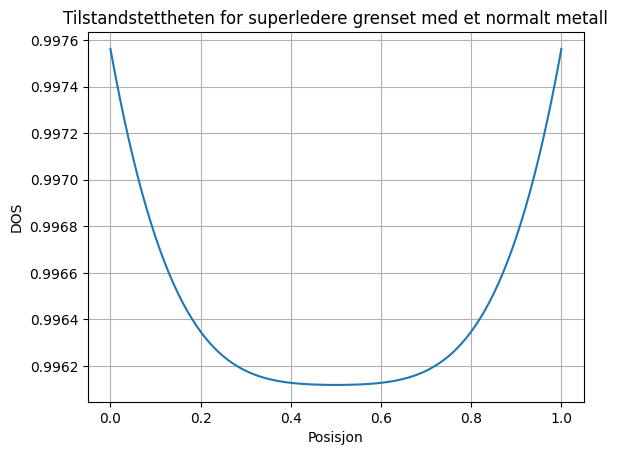

In [13]:
def oppgave_2j():
    eps = 2
    l = 1
    delta = 0.01
    zeta = 3
    m = 101
    x = jnp.linspace(0, l, m)
    y = jnp.zeros((32,m))
    phiL = phiR = 0

    partial_dvec     =  partial(calc_dvec, eps=eps, delta=delta)
    partial_boundary =  partial(calc_boundary_superconduct_metals, 
                                eps=eps, delta=delta, zeta=zeta, l=l,
                                phiL=phiL, phiR=phiR)


    sol = sp.integrate.solve_bvp(partial_dvec, partial_boundary, x, y)
    greensFunctions = jax.vmap(CalculateGreensFunction, in_axes=1)(sol["y"])
    density = jax.vmap(CalculateDensityOfState)(greensFunctions).squeeze(axis=-1)
    plt.plot(x, density)
    plt.grid()
    plt.xlabel("Posisjon")
    plt.ylabel("DOS")
    plt.title("Tilstandstettheten for superledere grenset med et normalt metall")
    plt.show()

oppgave_2j()

I figur 1 ser vi at tilstandstettheten for $E - E_F = 2 |\Delta| \iff \varepsilon = 2$ er noe større enn 1. Dermed er det flere tilgjengelige tilstander for disse elektronene i superledende fase enn i normal fase for det superledende materiale. På grunn av The Proximity Effect ("nærhetseffekten") vil denne økningen i antall tilstander "lekke" inn i det normale metallet. Dette gjør at kantene på metallet i normal fase vil ha høyere tilstandstetthet enn ved sentrum i $x = \frac{l}{2}$. Dermed er det å forvente at resultatene vil være likere de i oppgave h, med tilnærmet kontant verdi. 

Når vi plotter dette ser vi at tilstandstettheten er noe lavere i det normale metallet når det grenser til superledere enn når det ikke gjør det. Den forutsatte formen på den plottede kurven stemmer, men ved vår forståelse burde punktene $x \in \{ 0, l\}$ ha tilstandstetthet noe større enn 1 gitt tilstanden i superlederene ved denne energien.


## 2k)

100%|██████████| 101/101 [00:05<00:00, 19.91it/s]


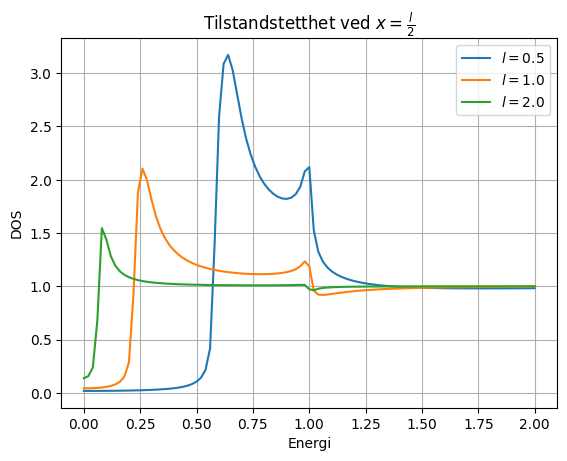

In [14]:
def oppgave_2k():

    epsilon = jnp.linspace(2,0,101)
    lengths = jnp.array((0.5,1,2))
    delta = 0.01
    zeta = 3
    phiL = phiR = 0
    xm = 101

    y = jnp.zeros((32,xm))
    for l in lengths:
        greensFunctions = list()
        x = jnp.linspace(0,l,xm)
        for eps in tqdm(epsilon):
            partial_dvec = partial(calc_dvec, eps=eps, delta=delta)
            partial_boundary = partial(calc_boundary_superconduct_metals, 
                                       eps=eps, delta=delta, zeta=zeta, l=l,
                                       phiL=phiL, phiR=phiR)

            solution = sp.integrate.solve_bvp(partial_dvec, partial_boundary, x, y, max_nodes = xm)
            y = solution["y"]
            solutionAtX_2 = solution["y"][:, ((xm)//2)]
            greensFunctions.append(CalculateGreensFunction(solutionAtX_2))


        greensFunctions = jnp.array(greensFunctions, dtype=jnp.complex128)
        DOS = jax.vmap(CalculateDensityOfState)(greensFunctions).flatten()
        plt.plot(epsilon, DOS, label = r"$l =$" + str(float(l)))
    
    plt.grid()
    plt.xlabel("Energi")
    plt.ylabel("DOS")
    plt.title(r"Tilstandstetthet ved $x = \frac{l}{2}$")
    plt.legend()
    plt.show()

oppgave_2k()

Det superledende gapet dukker opp for lavere energier. Vi ser også at etterhvert som lengden av den normale fasen øker minker mengden energier som inngår i gapet. Dette skyldes at nærhetseffekten avtar etterhvert som avstanden mellom superlederene øker. Om vi skal gjette tipper vi det skyldes at sannsynligheten for tunnelering synker. 

Videre ser vi at for $\varepsilon > 1$ jevner tilstandstettheten ut og går mot den normale fasen, noe som likner på det vi ser i fig 1. Dette er å forvente ettersom vi når energier som er større enn fermienergien, hvilket lar elektroner nå de lendene båndene. Materialet får da normale ledeevner, hvilket stemmer overens med oppg j.


## 2L)

100%|██████████| 101/101 [00:05<00:00, 18.88it/s]


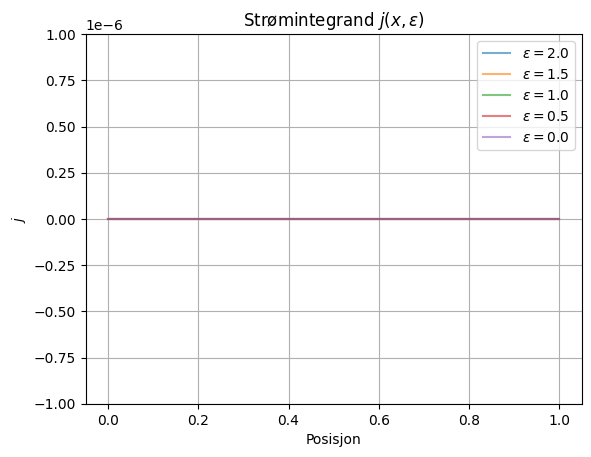

In [25]:
@jax.jit
def calculate_greens_function_derivative(solution):
    gamma, gamma_tilde, omega, omega_tilde = convert_vector_to_matrices(solution)

    N = calc_N(gamma, gamma_tilde)
    N_tilde = calc_N_tilde(gamma, gamma_tilde)

    N_derivative = jnp.einsum('ij,jk,kl', N, omega @ gamma_tilde + gamma @ omega_tilde, N)
    N_tilde_derivative = jnp.einsum('ij,jk,kl', N_tilde, omega_tilde @ gamma + gamma_tilde @ omega, N_tilde)

    topLeft = N_derivative
    topRight = N @ omega + N_derivative @ gamma
    bottomLeft = -N_tilde @ omega_tilde - N_tilde_derivative @ gamma_tilde
    bottomRight = -N_tilde_derivative

    dgreens = 2 * jnp.block([[topLeft, topRight], [bottomLeft, bottomRight]])
    return dgreens

@jax.jit
def find_current_at_single_point(greensFunction, dgreensFunction):
    roHat3 = jnp.array(((1,0,0,0),(0,1,0,0),(0,0,-1,0),(0,0,0,-1)))
    current = jnp.real(jnp.einsum('ij, ji ->',  roHat3, greensFunction @ dgreensFunction - dgreensFunction @ greensFunction))
    return current

def calculate_currents(lengths, epsilon, phiLeft, phiRight, find_current_for_all_positions=False, show_progress=True):
    epsN = len(epsilon)
    zeta = 3
    delta = 0.01
    l = 1

    currents = []
    xm = epsN
    x = jnp.linspace(0,l,xm)
    y = jnp.zeros((32,xm))

    phiR = phiRight
    for phiL in phiLeft:
        for l in lengths:
            for eps in (tqdm(epsilon) if show_progress else epsilon):
                partial_dvec = partial(calc_dvec, eps=eps, delta=delta)
                partial_boundary = partial(calc_boundary_superconduct_metals, 
                                       eps=eps, delta=delta, zeta=zeta, l=l,
                                       phiL=phiL, phiR=phiR)
                
                
                solution = sp.integrate.solve_bvp(partial_dvec, partial_boundary, x, y, max_nodes = xm, tol=1E-6)
                y = solution["y"]
                if find_current_for_all_positions:
                    greensFunctions = jax.vmap(CalculateGreensFunction, in_axes=1)(y)
                    dgreensFunctions = jax.vmap(calculate_greens_function_derivative, in_axes=1)(y)
                    currents.append(jax.vmap(find_current_at_single_point, in_axes=(0,0))(greensFunctions, dgreensFunctions))
                    #print(f'All currents has been calculated for eps = {eps :.2f} | Length = {l :.2f} | PhiL = {phiL :.2f}.')
                else:
                    y_singlePoint = solution["y"][:, (xm//2)]  # X = l/2
                    greensFunction = CalculateGreensFunction(y_singlePoint)
                    dgreensFunction = calculate_greens_function_derivative(y_singlePoint)
                    currents.append(find_current_at_single_point(greensFunction, dgreensFunction))
                    #print(f"Current at x=l/2 has been calculated for eps = {eps :.2f} | Length = {l :.2f} | PhiL = {phiL :.2f}")           
                
    return x, jnp.array(currents)


def oppgave_2l():
    epsilon_for_calculation = jnp.linspace(2,0,101)
    epsilon_for_plotting = jnp.array([2, 1.5, 1, 0.5, 0])
    plot_indices = jnp.isin(epsilon_for_calculation, epsilon_for_plotting)
    lengths = [1]
    phiLeft = [0] # Må være liste fordi programmet støtter iterering gjennom flere verdier
    phiRight = 0
    x, current = calculate_currents(lengths, epsilon_for_calculation, phiLeft, phiRight, find_current_for_all_positions=True)
    current_plot_vals = current[plot_indices]
    for (idx, current) in enumerate(current_plot_vals):
        plt.plot(x, current, label=f'$\\varepsilon = {epsilon_for_plotting[idx]}$', alpha=0.6)
    
    plt.grid()
    plt.title("Strømintegrand $j(x,\\varepsilon)$")
    plt.xlabel("Posisjon")
    plt.ylabel("$j$")
    plt.ylim(-1E-6, 1E-6)
    plt.legend()
    plt.show()

oppgave_2l()


Som vist i plottet er strøm-integranden lik null for alle energiene. Dersom man ikke koder inn grenser for y-aksen vil det vise variasjoner på størrelsesordenen $10^{-15}$, men ettersom toleransen på solveren til scipy er satt til $10^{-6}$ er dette et resultat av begrensninger i numerisk beregning og ikke et fysisk resultat.


## 2m)

100%|██████████| 101/101 [00:04<00:00, 21.22it/s]


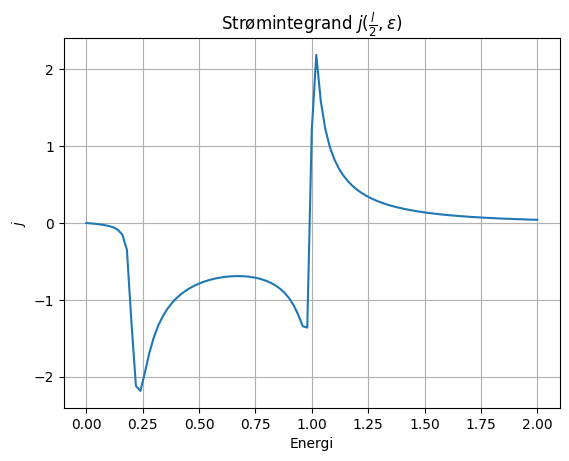

100%|██████████| 101/101 [00:04<00:00, 20.93it/s]


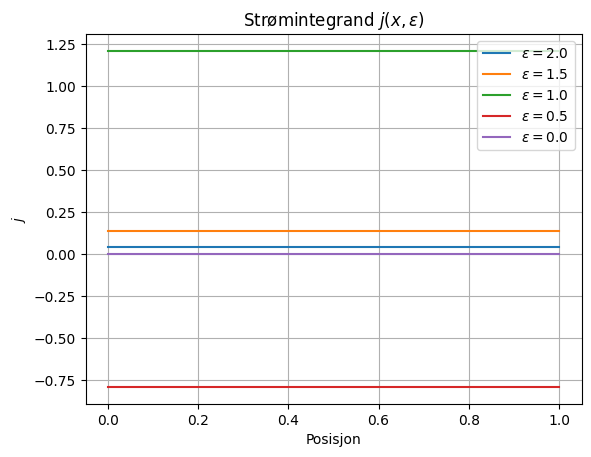

In [21]:
def oppgave_2m():
    phiLeft = [1]
    phiRight = 0
    epsilon = jnp.linspace(2,0,101)
    epsilon_for_position_plotting = jnp.array([2, 1.5, 1, 0.5, 0])
    plot_indices = jnp.isin(epsilon, epsilon_for_position_plotting)
    lengths = jnp.array([1])

    x, current_plot_vals = calculate_currents(lengths, epsilon, phiLeft, phiRight)
    plt.plot(epsilon, current_plot_vals)
    
    plt.grid()
    plt.title("Strømintegrand $j(\\frac{l}{2}, \\varepsilon)$")
    plt.xlabel("Energi")
    plt.ylabel("$j$")
    plt.show()

    plt.clf() 

    x, current = calculate_currents(lengths, epsilon, phiLeft, phiRight, find_current_for_all_positions=True)
    current_plot_vals = current[plot_indices]
    for (idx, current) in enumerate(current_plot_vals):
        plt.plot(x, current, label=f'$\\varepsilon = {epsilon_for_position_plotting[idx]}$')
    
    plt.grid()
    plt.title("Strømintegrand $j(x,\\varepsilon)$")
    plt.xlabel("Posisjon")
    plt.ylabel("$j$")
    plt.legend()
    plt.show()

oppgave_2m()

Nå som $\Delta\phi\neq0$ får vi som forventet en strøm i metallet, i motsetning til oppgave 2l. Dersom vi istedenfor energi plotter strømmen som funksjon av posisjon for fem utvalgte verdier av epsilon slik som i oppgave 2l ser vi likevel at strømintegranden også her er konservert ettersom den er konstant for alle x, noe som oppfyller bevaringskravet $j(x,\varepsilon) = j(0,\varepsilon)$.

At integranden en konservert gir mening gitt bevaringslovene. Fra energibevaring har vi at dersom et elektron går fra energinivå $\varepsilon_n$ til $\varepsilon_k$ må et annet elektron gjøre det motsatte for at energien skal bevares. Ladnings- og massebevaring tilsier at det ikke spontant kan oppstå nye elektroner. Elektrostatikk tilsier da at dersom elektroner flyter fra et område vil det oppstå en positiv ladning og systemet vil dras mot likevekt. Dermed må integranden være konstant.

## 2n)

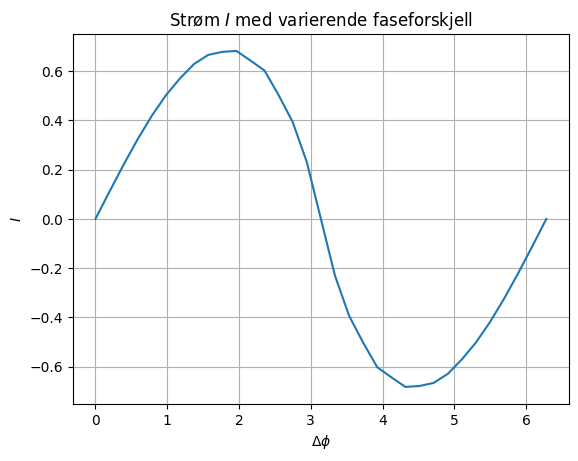

In [27]:
def integerate_currents(lengths, epsilon, phiLeft, phiRight, show_progress):
    Integrals = []
    x, currents = calculate_currents(lengths, epsilon, phiLeft, phiRight, show_progress=show_progress)
    current_per_phi = currents.reshape(-1, len(epsilon))
    for current in current_per_phi:
        this_integral = sp.integrate.simpson(current, epsilon)
        Integrals.append(this_integral)
    
    return jnp.array(Integrals)

def oppgave_2n():
    phiLeft = jnp.linspace(0, 2*jnp.pi, 33)
    phiRight = 0
    epsilon = jnp.linspace(2,0,101)
    lengths = jnp.array([1])

    Integrals = integerate_currents(lengths, epsilon, phiLeft, phiRight, show_progress=False)
    plt.plot(phiLeft, Integrals)
    plt.xlabel("$\\Delta\\phi$")
    plt.ylabel("$I$")
    plt.title("Strøm $I$ med varierende faseforskjell")
    plt.grid()
    plt.show()

oppgave_2n()

Vi observerer at strømmen øker for økende $\Delta\phi$ inntil et maksimum ved $\Delta\phi = \frac{\pi}{2}$, og den synker deretter til 0 ved $\Delta\phi=\pi$. Deretter speiles den om y-aksen i intervallet $(\pi, 2\pi)$. Med andre ord kan strømmen tilnærmes med en sinusfunksjon. Strømmen er altså periodisk i $\Delta\phi$ med perioden p = $2\pi$.

Videre observerer vi at den sinusodiale formen til $J(\Delta\phi)$ har noen overtoner. Disse har ikke store utslag og blir kun tydelige når vi har høy oppløsning langs $\Delta \phi$-aksen. Vi vet ikke om dette er resultat av at vi integrerer over et mindre intervall for $\varepsilon$ enn det som anses som standard (ref *a* i oppgaveteksten) eller om dette er et faktisk fysisk fenomen som kan observeres.